# Diabetes Prediction with ML

## The main objective of the project is to predict if patient is having diabetes or not 

In [1]:
# Steps Followed:
# -> We have used Pima Dataset giving by our professor
# -> Loaded data into jupyter notebook using pandas
# -> Performed data cleaning, split the data into train and test, trained the model, evaluated and imporved the performance of the model

In [2]:
# Models used: Naive Bayes, Random Forest, K-nearest neighbors
# conclusion: we have decided Random Forest as the best model since its accuracy:, precision:, recall:, F1 score:, 

In [3]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
# importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [5]:
#Data-Loading
df = pd.read_excel('pima-data.xlsx')
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


##### Data Cleaning Steps:
##### -> Treating null values
##### -> Remove duplicate rows & columns
##### -> Finding co-realted columns
##### -> Converting categorical data to numeric data
##### -> Replacing zeros in the input columns
##### -> Standardizing the data
##### -> Removing low impactfull columns
##### -> Balancing the data

<a id='null'></a>
#### Treating null values steps:

In [6]:
# stp1: check if dataset contains null values
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

In [7]:
# Remove duplicate rows & columns

In [8]:
# checking duplicate rows
df[df.duplicated()]

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes


In [9]:
# checking duplicate columns
df.T.duplicated()

num_preg         False
glucose_conc     False
diastolic_bp     False
thickness        False
insulin          False
bmi              False
diab_pred        False
age              False
diabetes_orig    False
skin             False
has_diabetes      True
diabetes          True
dtype: bool

In [10]:
# Out of duplicate columns has_diabetes & diabetes dropping any column
df.drop(['diabetes','has_diabetes'], axis = 1, inplace = True)

In [11]:
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin
0,6,148,72,35,0,33.6,0.627,50,1,1.3790
1,1,85,66,29,0,26.6,0.351,31,0,1.1426
2,8,183,64,0,0,23.3,0.672,32,1,0.0000
3,1,89,66,23,94,28.1,0.167,21,0,0.9062
4,0,137,40,35,168,43.1,2.288,33,1,1.3790


## Droping co-related columns

In [12]:
# Checking which columns are co-related
df.corr().style.background_gradient(cmap='coolwarm')

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898,-0.081672
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581,0.057328
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068,0.207371
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548,0.436783
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695,0.392573
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844,0.183928
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356,-0.113970
diabetes_orig,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000,0.074752
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000


In [13]:
#co-related columns 
# 1. skin & thickness

In [14]:
#checking if skin and thickness are duplicate columns
difference = df['skin']- df['thickness']

In [15]:
difference

0     -33.6210
1     -27.8574
2       0.0000
3     -22.0938
4     -33.6210
        ...   
763   -46.1088
764   -25.9362
765   -22.0938
766     0.0000
767   -29.7786
Length: 768, dtype: float64

In [16]:
# Skin & thickness not duplicate columns
# To decide which col to drop checking its corelation with output column
cor_col = df[['skin', 'thickness', 'diabetes_orig']]
cor_col.corr().style.background_gradient(cmap='coolwarm')

,skin,thickness,diabetes_orig
skin,1.000000,1.000000,0.074752
thickness,1.000000,1.000000,0.074752
diabetes_orig,0.074752,0.074752,1.000000


In [17]:
# the absolute value of both against diabetes_orig is same so drop any column
df.drop('skin', axis = 1, inplace = True)

In [18]:
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Convert categorical data to numeric
##### No categorical data present

### Replace zero values with mean

In [19]:
# Checking if zero values present
(df == 0).sum()

num_preg         111
glucose_conc       5
diastolic_bp      35
thickness        227
insulin          374
bmi               11
diab_pred          0
age                0
diabetes_orig    500
dtype: int64

In [20]:
# creating a new dataset without the output column
# because we dont want to replace output column 0's which says diabetes not present
zero_col = df.drop('diabetes_orig', axis = 1)

In [21]:
zero_col.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [22]:
# To get correct mean value converting all zeros null values 
zero_col.replace(0, pd.NA, inplace = True).head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age
0,6,148,72,35,<NA>,33.6,0.627,50
1,1,85,66,29,<NA>,26.6,0.351,31
2,8,183,64,<NA>,<NA>,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,<NA>,137,40,35,168,43.1,2.288,33


In [23]:
# Replacing all Null values with mean
fill_data = {'num_preg':df['num_preg'].mean(),
            'glucose_conc':df['glucose_conc'].mean(),
            'diastolic_bp':df['diastolic_bp'].mean(),
            'thickness':df['thickness'].mean(),
            'insulin':df['insulin'].mean(),
            'bmi':df['bmi'].mean()}

zero_col.fillna(fill_data, inplace = True)

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age
0,6,148,72,35,79.799479,33.6,0.627,50
1,1,85,66,29,79.799479,26.6,0.351,31
2,8,183,64,20.536458,79.799479,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,3.845052,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,79.799479,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,20.536458,79.799479,30.1,0.349,47


In [24]:
# Cross checking if any Null value present
zero_col.isnull().sum()

num_preg        0
glucose_conc    0
diastolic_bp    0
thickness       0
insulin         0
bmi             0
diab_pred       0
age             0
dtype: int64

### Standardizing/Normalization

In [25]:
# if data has outliers then perform Standardization else normalization
# Checking if outliers present

{'whiskers': [<matplotlib.lines.Line2D at 0x1e4d97d9e80>,
 'caps': [<matplotlib.lines.Line2D at 0x1e4d97da120>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e4d97d9d30>],
 'medians': [<matplotlib.lines.Line2D at 0x1e4d97da3c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e4d97da510>],
 'means': []}

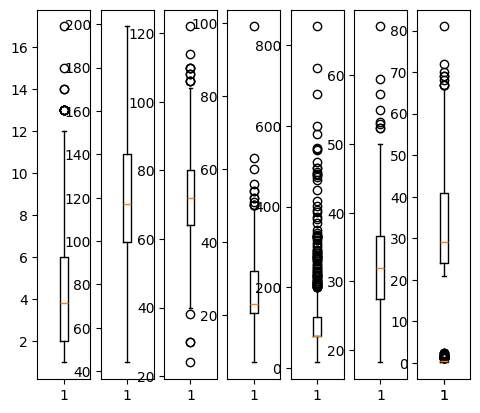

In [26]:
# Checking any global outlier present for each column
plt.subplot(1, 8, 1)
plt.boxplot(zero_col['num_preg'])
plt.subplot(1, 8, 2)
plt.boxplot(zero_col['glucose_conc'])
plt.subplot(1, 8, 3)
plt.boxplot(zero_col['diastolic_bp'])
plt.subplot(1, 8, 4)
plt.boxplot(zero_col['thickness'])
plt.subplot(1, 8, 5)
plt.boxplot(zero_col['insulin'])
plt.subplot(1, 8, 6)
plt.boxplot(zero_col['bmi'])
plt.subplot(1, 8, 7)
plt.boxplot(zero_col['diab_pred'])
plt.subplot(1, 8, 7)
plt.boxplot(zero_col['age'])

In [27]:
# Since outliers present performing standardinzation over normalization

In [28]:
### z-score standardization = (data_point1 - Column_mean) + (data_point1 - Column_mean) +....+ (data_point1 - Column_mean)          
###                           -------------------------------------------------------------------------------------------
###                                                           Standard_deviation
### Standard_deviation = Square root of Variance

### Variance = ((data_point1 - Column_mean)**2) + ((data_point2 - Column_mean)**2) +...+ ((data_point_n - Column_mean)**2)
###            -----------------------------------------------------------------------------------------------------------
###                                               len(column)

In [29]:
# stp1 find each column mean
col_mean = zero_col.mean()
col_mean

num_preg          4.400782
glucose_conc    121.681605
diastolic_bp     72.254807
thickness        26.606479
insulin         118.660163
bmi              32.450805
diab_pred         0.471876
age              33.240885
dtype: object

In [30]:
# stp1 find standard deviation of entire dataset
# ddof is delta degree of freedom
dataset_std = zero_col.std(ddof = 0)
dataset_std

num_preg         2.982218
glucose_conc    30.416194
diastolic_bp    12.108041
thickness        9.624968
insulin         93.019739
bmi              6.870896
diab_pred        0.331113
age             11.752573
dtype: object

In [31]:
# applying z-score standardization on entire data
zero_col_standardized = (zero_col-col_mean)/dataset_std
zero_col_standardized.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age
0,0.536251,0.865276,-0.021044,0.872057,-0.417768,0.167255,0.468492,1.425995
1,-1.140353,-1.205989,-0.516583,0.248678,-0.417768,-0.851535,-0.365061,-0.190672
2,1.206893,2.015979,-0.681762,-0.630654,-0.417768,-1.331821,0.604397,-0.105584
3,-1.140353,-1.07448,-0.516583,-0.3747,-0.265107,-0.633222,-0.920763,-1.041549
4,-0.186348,0.503626,-2.663916,0.872057,0.530423,1.549899,5.484909,-0.020496


### Removing unwanted columns

In [32]:
# lets find out which are the non impactfull column to the output varible
zero_col_standardized.corr().style.background_gradient(cmap='coolwarm')


,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age
num_preg,1.000000,0.152568,0.253275,0.045776,-0.016738,0.097663,-0.010297,0.525261
glucose_conc,0.152568,1.000000,0.219666,0.160766,0.396597,0.231478,0.137106,0.266600
diastolic_bp,0.253275,0.219666,1.000000,0.134155,0.010926,0.281231,0.000371,0.326740
thickness,0.045776,0.160766,0.134155,1.000000,0.240361,0.535703,0.154961,0.026423
insulin,-0.016738,0.396597,0.010926,0.240361,1.000000,0.189856,0.157806,0.038652
bmi,0.097663,0.231478,0.281231,0.535703,0.189856,1.000000,0.153508,0.025748
diab_pred,-0.010297,0.137106,0.000371,0.154961,0.157806,0.153508,1.000000,0.033561
age,0.525261,0.266600,0.326740,0.026423,0.038652,0.025748,0.033561,1.000000


In [33]:
# Only subject matter expert can tell us which are unwanted columns

### Data Balancing

In [34]:
# Checking How many 1's & 0's present in the data
num_of_1 = df[df['diabetes_orig'] == 1]['diabetes_orig'].count()
num_of_0 = df[df['diabetes_orig'] == 0]['diabetes_orig'].count()

In [35]:
# Caculating percentage of 1's & 0's present in the data
percent_of_1 = (num_of_1/768)*100
percent_of_0 = (num_of_0/768)*100

In [36]:
percent_of_1

np.float64(34.89583333333333)

In [37]:
percent_of_0

np.float64(65.10416666666666)

<BarContainer object of 2 artists>

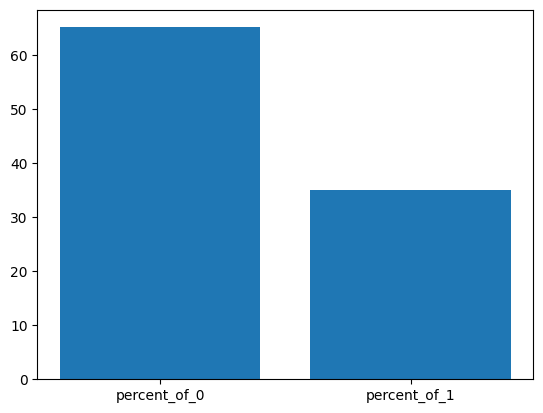

In [38]:
# Plotting graph of the each calss percentage
x_axis = ['percent_of_0', 'percent_of_1']
y_axis = [percent_of_0, percent_of_1]
plt.bar(x_axis, y_axis)

In [39]:
# Performing upsampling of minority class
input_col = zero_col_standardized
output_col = df.iloc[:,-1]

smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(input_col, output_col)

In [40]:
#cross checking if data is balanced
y_resampled.value_counts()

diabetes_orig
1    500
0    500
Name: count, dtype: int64

### Train Test Split

In [45]:
# Splitting the input columns and prediction columns
x = X_resampled
y = y_resampled

In [46]:
# Split data into train and test set
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [47]:
#Checking class balance in the train data
y_train.value_counts()

diabetes_orig
0    351
1    349
Name: count, dtype: int64

### Training the 3 different models

In [54]:
# Traning the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(x_train, y_train.values.ravel())

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[351.,349.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.015e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['num_preg','glucose_conc','diastolic_bp',...,'bmi','diab_pred','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.22,-0.35,-0.11,...,-0.23,-0.09,-0.2 ], [ 0.28, 0.66, 0.2 ,..., 0.42, 0.24, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.63,0.97,...,0.93,0.87,0.98], [0.99,0.89,0.91,...,0.74,0.98,0.76]]"


In [91]:
# Traning the Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [93]:
# Traning the KNN model
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train.values.ravel())

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [95]:
# Testing the Naive Bayes model using train data
nb_train_data_predict = nb_model.predict(x_train)

In [96]:
# Testing the Random Forest model using train data
rf_train_data_predict = rf_model.predict(x_train)

In [97]:
# Testing the KNN model using train data
knn_train_data_predict = knn_model.predict(x_train)

In [98]:
# checking Naive Bayes Model Accuracy on train data
nb_train_data_correct_pred = (y_train == nb_train_data_predict).sum()
nb_train_accuracy = (nb_train_data_correct_pred/len(y_train))*100
print(f'the Naive Bayes Model model acuracy on train data is: {int(nb_train_accuracy)}%')

the Naive Bayes Model model acuracy on train data is: 71%


In [99]:
# checking Random Forest Model Accuracy on train data
rf_train_data_correct_pred = (y_train == rf_train_data_predict).sum()
rf_train_accuracy = (rf_train_data_correct_pred/len(y_train))*100
print(f'the Random Forest model acuracy on train data is: {int(rf_train_accuracy)}%')

the Random Forest model acuracy on train data is: 100%


In [101]:
# checking KNN Model Accuracy on train data
knn_train_data_correct_pred = (y_train == knn_train_data_predict).sum()
knn_train_accuracy = (knn_train_data_correct_pred/len(y_train))*100
print(f'the KNN model acuracy on train data is: {int(knn_train_accuracy)}%')

the KNN model acuracy on train data is: 84%


In [78]:
# Testing the Naive Bayes model using test data
nb_test_data_predict = nb_model.predict(x_test)

In [102]:
# Testing the Random Forest model using test data
rf_test_data_predict = rf_model.predict(x_test)

In [103]:
# Testing the KNN model using test data
knn_test_data_predict = knn_model.predict(x_test)

In [104]:
# checking Naive Bayes Model Accuracy on train data
nb_test_data_correct_pred = (y_test == nb_test_data_predict).sum()
nb_test_accuracy = (nb_test_data_correct_pred/len(y_test))*100
print(f'the Naive Bayes model acuracy on test data is: {int(nb_test_accuracy)}%')

the Naive Bayes model acuracy on test data is: 73%


In [106]:
# checking Random Forest Model Accuracy on train data
rf_test_data_correct_pred = (y_test == rf_test_data_predict).sum()
rf_test_accuracy = (rf_test_data_correct_pred/len(y_test))*100
print(f'the Random Forest model acuracy on test data is: {int(rf_test_accuracy)}%')

the Random Forest model acuracy on test data is: 77%


In [107]:
# checking KNN Model Accuracy on train data
knn_test_data_correct_pred = (y_test == knn_test_data_predict).sum()
knn_test_accuracy = (knn_test_data_correct_pred/len(y_test))*100
print(f'the KNN model acuracy on test data is: {int(knn_test_accuracy)}%')

the KNN model acuracy on test data is: 75%


In [108]:
# confusion metrics for Naive Bayes Model
print(f'{metrics.confusion_matrix(y_test, nb_test_data_predict)} confusion metrics of Naive Bayes Model')

[[121  28]
 [ 51 100]] confusion metrics of Naive Bayes Model


In [109]:
# confusion metrics for Random Forest Model
print(f'{metrics.confusion_matrix(y_test, rf_test_data_predict)} confusion metrics of Random Forest Model')

[[110  39]
 [ 28 123]] confusion metrics of Random Forest Model


In [110]:
# confusion metrics for KNN Model
print(f'{metrics.confusion_matrix(y_test, knn_test_data_predict)} confusion metrics of KNN Model')

[[ 98  51]
 [ 22 129]] confusion metrics of KNN Model


In [116]:
# Classification report for Naive Bayes Model
print(f'Classification report of Naive Bayes Model \n {metrics.classification_report(y_test, nb_test_data_predict)} ')

Classification report of Naive Bayes Model 
               precision    recall  f1-score   support

           0       0.70      0.81      0.75       149
           1       0.78      0.66      0.72       151

    accuracy                           0.74       300
   macro avg       0.74      0.74      0.74       300
weighted avg       0.74      0.74      0.74       300
 


In [117]:
# Classification report for Random Forest Model
print(f'Classification report of Random Forest Model \n {metrics.classification_report(y_test, rf_test_data_predict)} ')

Classification report of Random Forest Model 
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       149
           1       0.76      0.81      0.79       151

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300
 


In [118]:
# Classification report for KNN Model
print(f'Classification report of KNN Model \n {metrics.classification_report(y_test, knn_test_data_predict)} ')

Classification report of KNN Model 
               precision    recall  f1-score   support

           0       0.82      0.66      0.73       149
           1       0.72      0.85      0.78       151

    accuracy                           0.76       300
   macro avg       0.77      0.76      0.75       300
weighted avg       0.77      0.76      0.75       300
 


In [ ]:
## Conclusion: Random Forest is the best suitable model